# **Exploratory Data Analysis for the Waze Project**

### **Imports and data loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [2]:
# Load the dataset into a dataframe
df = pd.read_csv('waze_dataset.csv')

In [ ]:
# Output descriptive statistics of the dataset
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


In [ ]:
# Output the data type for each column in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [ ]:
# Verify if the data type for each column matches the stored data value
df.head(10)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone


### **Understanding the Distribution of Data**



In this section of the notebook, we will visualize the spread and distribution of the data using box plots and histograms for the following columns:
* **`drives`**: an occurrence of driving at least 1 km during the month
* **`driven_km_drives`**: total kilometers driven during the month
* **`duration_minutes_drives`**: total duration driven in minutes during the month
* **`activity_days`**: number of days the user opens the app during the month
* **`driving_days`**: number of days the user drives (at least 1 km) during the month

These columns were selected to determine whether any of them are associated with user churn.

#### **`drives`**

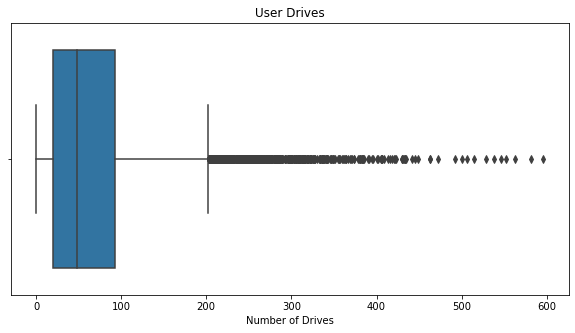

In [10]:
# Box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['drives'])

plt.xlabel('Number of Drives')
plt.title('User Drives')

plt.show()

In [11]:
drives_mean = df['drives'].mean()
drives_median = df['drives'].median()

print(f'Drives Mean:{drives_mean}')
print(f'Drives Median: {drives_median}')

Drives Mean:67.28115207680511
Drives Median: 48.0


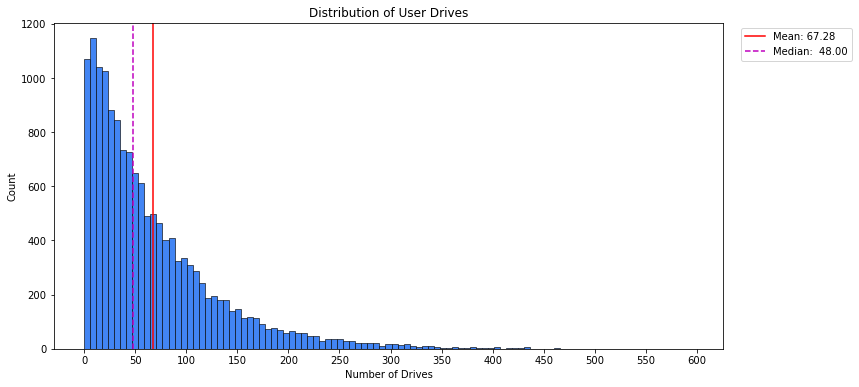

In [12]:
# Histogram
plt.figure(figsize=(12, 6))
ax = sns.histplot(df['drives'], bins='fd', color='#4285F4', alpha=1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))

plt.xlabel('Number of Drives')
plt.title('Distribution of User Drives')

plt.axvline(x=drives_mean, color='r', linestyle='solid',
            label=f'Mean:{drives_mean: .2f}')
plt.axvline(x=drives_median, color='m', linestyle='--',
            label=f'Median: {drives_median: .2f}')

plt.legend(bbox_to_anchor=(1.2,1))
plt.show()

**Observations:**
* The median was used to describe the center of the distribution because it is less sensitive to outliers than the mean. The median of **`drives`** is **48**.
* As shown in the histogram, the **`drives`** variable has a **right-skewed distribution**. This indicates that 50% of the users recorded 48 or fewer drives during the month, while a small number of users recorded as many as 300 drives suggesting the presence of outliers. 

#### **`driven_km_drives`**

_Total kilometers driven during the month_

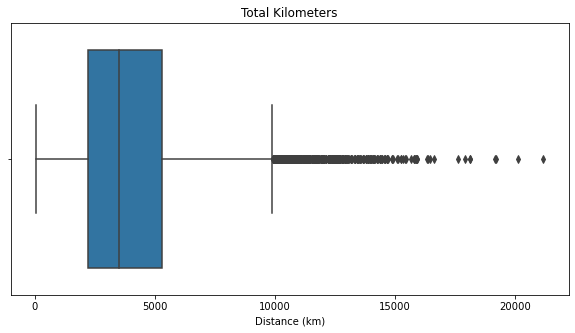

In [19]:
# Box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['driven_km_drives'])

plt.xlabel('Distance (km)')
plt.title('Total Kilometers')

plt.show()

In [20]:
driven_mean = df['driven_km_drives'].mean()
driven_median = df['driven_km_drives'].median()

print(f'Total Kilometers Mean:{driven_mean}')
print(f'Total Kilometers Median: {driven_median}')

Total Kilometers Mean:4039.3409208165035
Total Kilometers Median: 3493.858085


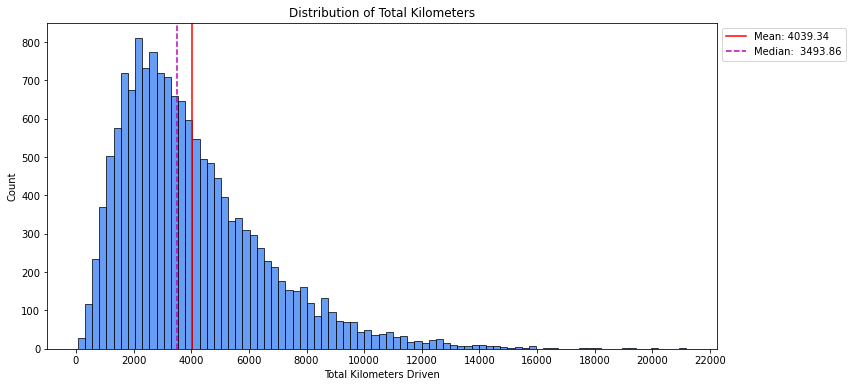

In [21]:
# Histogram
plt.figure(figsize=(12, 6))
ax = sns.histplot(df['driven_km_drives'], bins='fd', color='#4285F4', alpha=0.8)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2000))

plt.xlabel("Total Kilometers Driven")
plt.title('Distribution of Total Kilometers')

plt.axvline(x=driven_mean, color='r', linestyle='solid',
            label=f'Mean:{driven_mean: .2f}')
plt.axvline(x=driven_median, color='m', linestyle='--',
            label=f'Median: {driven_median: .2f}')

plt.legend(bbox_to_anchor=(1.2,1))
plt.show()

The number of drives driven in the last month per user is a right-skewed distribution with half the users driving under 3,495 kilometers. As you discovered in the analysis from the previous course, the users in this dataset drive _a lot_. The longest distance driven in the month was over half the circumferene of the earth.

#### **`duration_minutes_drives`**

_Total duration driven in minutes during the month_

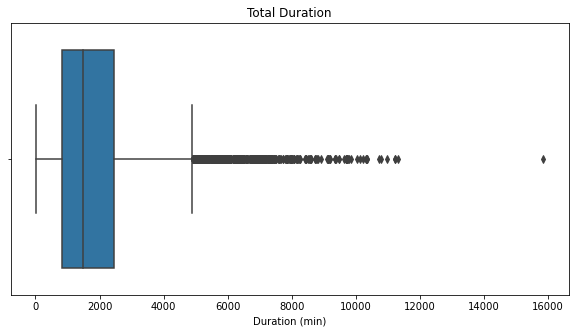

In [22]:
# Box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['duration_minutes_drives'])

plt.xlabel('Duration (min)')
plt.title('Total Duration')

plt.show()

In [23]:
duration_mean = df['duration_minutes_drives'].mean()
duration_median = df['duration_minutes_drives'].median()

print(f'Total Duration Mean:{duration_mean}')
print(f'Total Duration Median: {duration_median}')

Total Duration Mean:1860.9760121293946
Total Duration Median: 1478.249859


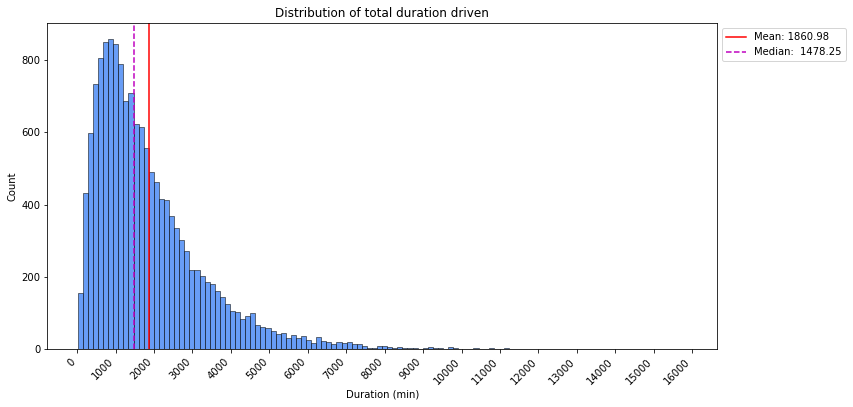

In [24]:
# Histogram
plt.figure(figsize=(12, 6))
ax = sns.histplot(df['duration_minutes_drives'], bins='fd', color='#4285F4', alpha=0.8)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))

plt.xticks(rotation=45, horizontalalignment='right')
plt.xlabel("Duration (min)")
plt.title('Distribution of total duration driven')

plt.axvline(x=duration_mean, color='r', linestyle='solid',
            label=f'Mean:{duration_mean: .2f}')
plt.axvline(x=duration_median, color='m', linestyle='--',
            label=f'Median: {duration_median: .2f}')

plt.legend(bbox_to_anchor=(1.2,1))
plt.show()

The `duration_minutes_drives` variable has a heavily skewed right tail. Half of the users drove less than \~1,478 minutes (\~25 hours), but some users clocked over 250 hours over the month.

#### **`activity_days`**

_Number of days the user opens the app during the month_

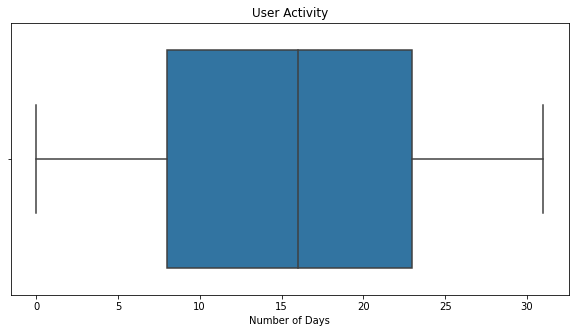

In [25]:
# Box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['activity_days'])

plt.xlabel('Number of Days')
plt.title('User Activity')

plt.show()

In [26]:
activity_mean = df['activity_days'].mean()
activity_median = df['activity_days'].median()

print(f'Activity Days Mean:{activity_mean}')
print(f'Activity Days Median: {activity_median}')

Activity Days Mean:15.537102473498233
Activity Days Median: 16.0


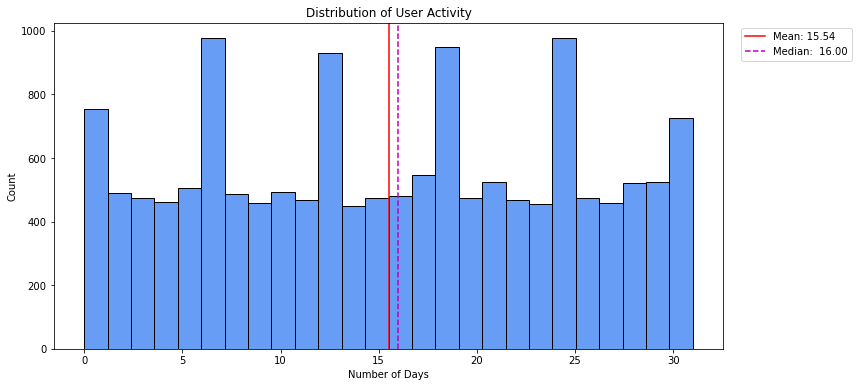

In [27]:
# Histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['activity_days'], bins='fd', color='#4285F4', alpha=0.8)

plt.xlabel('Number of Days')
plt.title('Distribution of User Activity')

plt.axvline(x=activity_mean, color='r', linestyle='solid',
            label=f'Mean:{activity_mean: .2f}')
plt.axvline(x=activity_median, color='m', linestyle='--',
            label=f'Median: {activity_median: .2f}')

plt.legend(bbox_to_anchor=(1.2,1))
plt.show()

Within the last month, users opened the app a median of 16 times. The box plot reveals a centered distribution. The histogram shows a nearly uniform distribution of ~500 people opening the app on each count of days. However, there are ~250 people who didn't open the app at all and ~250 people who opened the app every day of the month.

This distribution is noteworthy because it does not mirror the `sessions` distribution, which you might think would be closely correlated with `activity_days`.

#### **`driving_days`**

_Number of days the user drives (at least 1 km) during the month_

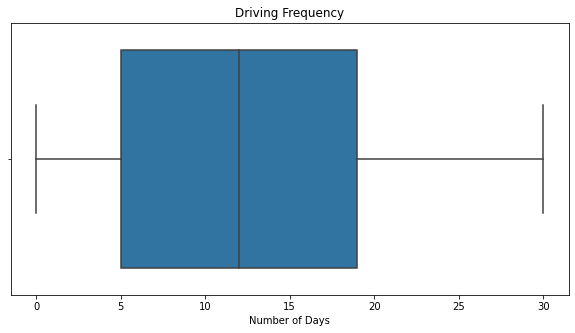

In [28]:
# Box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['driving_days'])

plt.xlabel('Number of Days')
plt.title('Driving Frequency')

plt.show()

In [29]:
driving_mean = df['driving_days'].mean()
driving_median = df['driving_days'].median()

print(f'Driving Days Mean:{driving_mean}')
print(f'Driving Days Median: {driving_median}')

Driving Days Mean:12.179878658577238
Driving Days Median: 12.0


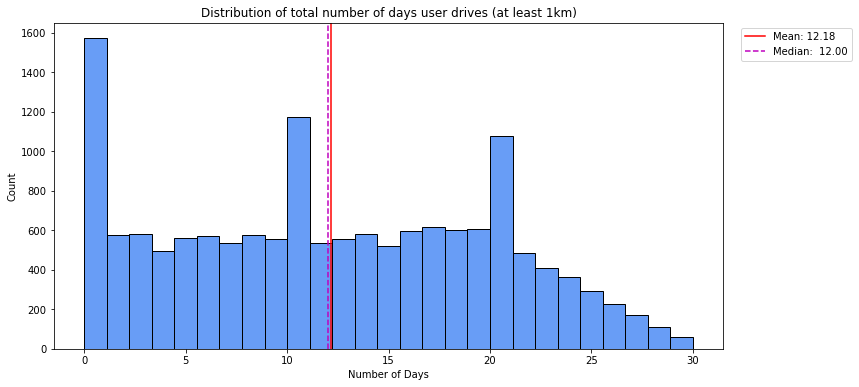

In [30]:
# Histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['driving_days'], bins='fd', color='#4285F4', alpha=0.8)

plt.xlabel('Number of Days')
plt.title('Distribution of total number of days user drives (at least 1km)')

plt.axvline(x=driving_mean, color='r', linestyle='solid',
            label=f'Mean:{driving_mean: .2f}')
plt.axvline(x=driving_median, color='m', linestyle='--',
            label=f'Median: {driving_median: .2f}')

plt.legend(bbox_to_anchor=(1.2,1))
plt.show()

The number of days users drove each month is almost uniform, and it largely correlates with the number of days they opened the app that month, except the `driving_days` distribution tails off on the right.

However, there were almost twice as many users (\~1,000 vs. \~550) who did not drive at all during the month. This might seem counterintuitive when considered together with the information from `activity_days`. That variable had \~500 users opening the app on each of most of the day counts, but there were only \~250 users who did not open the app at all during the month and ~250 users who opened the app every day. Flag this for further investigation later.

#### **`device`**

_The type of device a user starts a session with_

This is a categorical variable, so you do not plot a box plot for it. A good plot for a binary categorical variable is a pie chart.

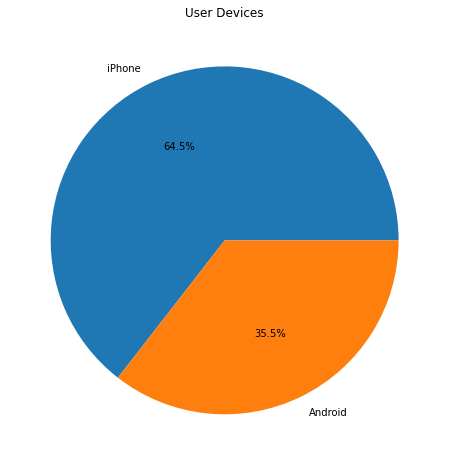

In [31]:
# Pie chart
device_counts = df['device'].value_counts()
plt.figure(figsize=(8, 8))

plt.pie(device_counts,
       labels=device_counts.index,
       autopct='%1.1f%%')

plt.title('User Devices')
plt.show()

There are nearly twice as many iPhone users as Android users represented in this data.

#### **`label`**

_Binary target variable (“retained” vs “churned”) for if a user has churned anytime during the course of the month_

This is also a categorical variable, and as such would not be plotted as a box plot. Plot a pie chart instead.

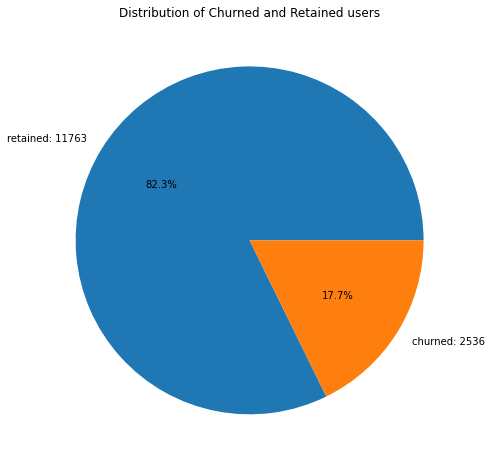

In [32]:
# Pie chart
label_counts = df['label'].value_counts()
plt.figure(figsize=(8, 8))

plt.pie(label_counts,
       labels=[f'{label_counts.index[0]}: {label_counts.values[0]}',
               f'{label_counts.index[1]}: {label_counts.values[1]}'],
       autopct='%1.1f%%')

plt.title('Distribution of Churned and Retained users')
plt.show()

Less than 18% of the users churned.

#### **`driving_days` vs. `activity_days`**

Because both `driving_days` and `activity_days` represent counts of days over a month and they're also closely related, you can plot them together on a single histogram. This will help to better understand how they relate to each other without having to scroll back and forth comparing histograms in two different places.

Plot a histogram that, for each day, has a bar representing the counts of `driving_days` and `activity_days`.

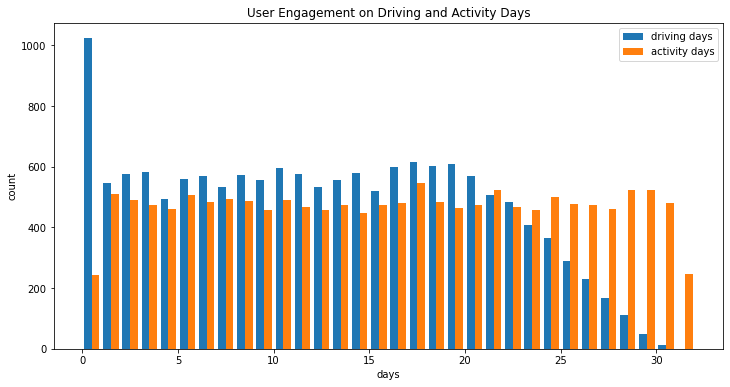

In [33]:
# Histogram
plt.figure(figsize=(12, 6))
labels = ['driving days', 'activity days']

plt.hist([df['driving_days'], df['activity_days']], 
         bins=range(0,33),
         label=labels)

plt.xlabel('days')
plt.ylabel('count')
plt.title('User Engagement on Driving and Activity Days')

plt.legend()
plt.show()

As observed previously, this might seem counterintuitive. After all, why are there _fewer_ people who didn't use the app at all during the month and _more_ people who didn't drive at all during the month?

On the other hand, it could just be illustrative of the fact that, while these variables are related to each other, they're not the same. People probably just open the app more than they use the app to drive&mdash;perhaps to check drive times or route information, to update settings, or even just by mistake.

Nonetheless, it might be worthwile to contact the data team at Waze to get more information about this, especially because it seems that the number of days in the month is not the same between variables.

Confirm the maximum number of days for each variable&mdash;`driving_days` and `activity_days`.

In [34]:
print(df['driving_days'].max())
print(df['activity_days'].max())

30
31


It's true. Although it's possible that not a single user drove all 31 days of the month, it's highly unlikely, considering there are 15,000 people represented in the dataset.

One other way to check the validity of these variables is to plot a simple scatter plot with the x-axis representing one variable and the y-axis representing the other.

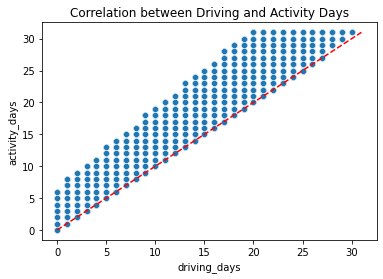

In [35]:
# Scatter plot
sns.scatterplot(data=df,
                x='driving_days',
                y='activity_days')

plt.title('Correlation between Driving and Activity Days')
plt.plot([0,31], [0,31], color='red', linestyle='--')
plt.show()

Notice that there is a theoretical limit. If you use the app to drive, then by definition it must count as a day-use as well. In other words, you cannot have more drive-days than activity-days. None of the samples in this data violate this rule, which is good.

#### **Retention by device**

Plot a histogram that has four bars&mdash;one for each device-label combination&mdash;to show how many iPhone users were retained/churned and how many Android users were retained/churned.

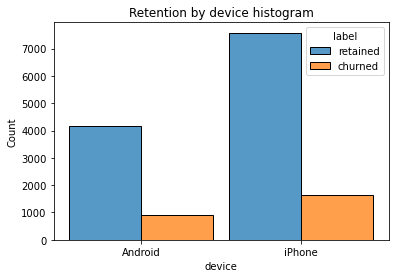

In [36]:
# Histogram
plt.figure(figsize=(6, 4))

sns.histplot(data=df,
             x='device',
             hue='label',
             multiple='dodge',
             shrink=0.9)

plt.title('Retention by device histogram')

plt.show()

The proportion of churned users to retained users is consistent between device types.

#### **Retention by kilometers driven per driving day**

In the previous course, you discovered that the median distance driven per driving day last month for users who churned was 697.54 km, versus 289.55 km for people who did not churn. Examine this further.

1. Create a new column in `df` called `km_per_driving_day`, which represents the mean distance driven per driving day for each user.

2. Call the `describe()` method on the new column.

In [37]:
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

df['km_per_driving_day'].describe()

count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [38]:
df.loc[df['km_per_driving_day']==np.inf, 'km_per_driving_day'] = 0

df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

The maximum value is 15,420 kilometers _per drive day_. This is physically impossible. Driving 100 km/hour for 12 hours is 1,200 km. It's unlikely many people averaged more than this each day they drove, so, for now, disregard rows where the distance in this column is greater than 1,200 km.

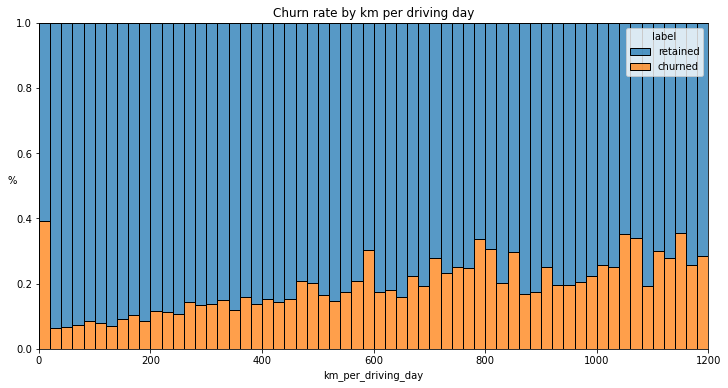

In [39]:
# Histogram
plt.figure(figsize=(12, 6))

sns.histplot(data=df,
             x='km_per_driving_day',
             bins = range(0, 1201, 20),
             hue='label',
             multiple='fill')

plt.ylabel('%', rotation=0)
plt.title('Churn rate by km per driving day')

plt.show()

The churn rate tends to increase as the mean daily distance driven increases, confirming what was found in the previous course. It would be worth investigating further the reasons for long-distance users to discontinue using the app.

#### **Churn rate per number of driving days**

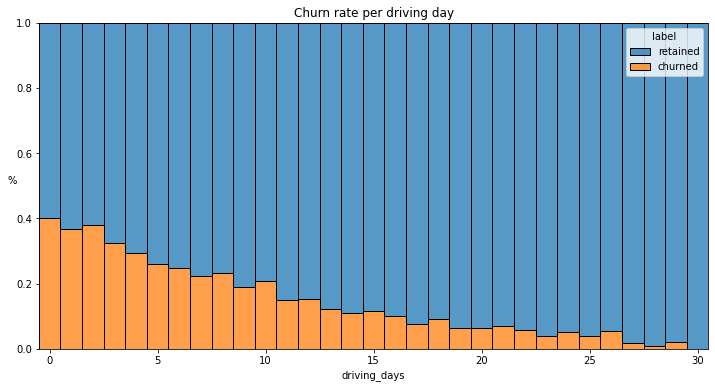

In [40]:
# Histogram
plt.figure(figsize=(12, 6))

sns.histplot(data=df,
             x='driving_days',
             bins = range(1,32),
             hue='label',
             multiple='fill',
             discrete=True)

plt.ylabel('%', rotation=0)
plt.title('Churn rate per driving day')

plt.show()

The churn rate is highest for people who didn't use Waze much during the last month. The more times they used the app, the less likely they were to churn. While 40% of the users who didn't use the app at all last month churned, nobody who used the app 30 days churned.

This isn't surprising. If people who used the app a lot churned, it would likely indicate dissatisfaction. When people who don't use the app churn, it might be the result of dissatisfaction in the past, or it might be indicative of a lesser need for a navigational app. Maybe they moved to a city with good public transportation and don't need to drive anymore.

#### **Proportion of sessions that occurred in the last month**

In [41]:
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

What is the median value of the new column?

In [42]:
df['percent_sessions_in_last_month'].median()

0.42309702992763176

Now, create a histogram depicting the distribution of values in this new column.

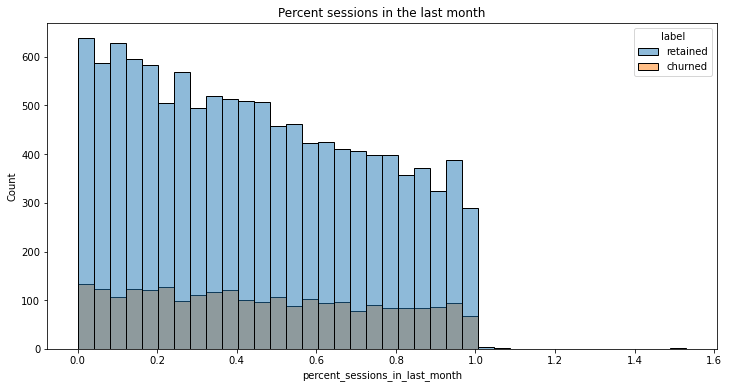

In [43]:
# Histogram
plt.figure(figsize=(12, 6))

sns.histplot(data=df,
             x='percent_sessions_in_last_month',
             hue='label',
             multiple='layer')

plt.title('Percent sessions in the last month')

plt.show()

Check the median value of the `n_days_after_onboarding` variable.

In [44]:
df['n_days_after_onboarding'].median()

1741.0

Half of the people in the dataset had 40% or more of their sessions in just the last month, yet the overall median time since onboarding is almost five years.

Make a histogram of `n_days_after_onboarding` for just the people who had 40% or more of their total sessions in the last month.

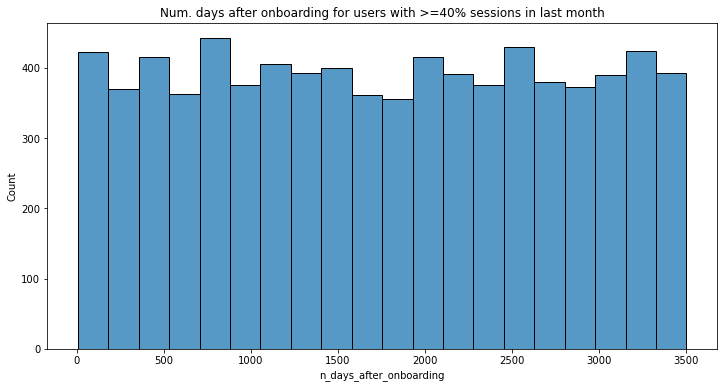

In [45]:
# Histogram
data = df.loc[df['percent_sessions_in_last_month']>=0.4]

plt.figure(figsize=(12, 6))

sns.histplot(data=data,
             x='n_days_after_onboarding')

plt.title('Num. days after onboarding for users with >=40% sessions in last month')

plt.show()

The number of days since onboarding for users with 40% or more of their total sessions occurring in just the last month is a uniform distribution. This is very strange. It's worth asking Waze why so many long-time users suddenly used the app so much in the last month.

### **Task 3b. Handling outliers**



In [46]:
# give a derive value for outliers
def outlier_imputer(column_name, percentile):
    # calculate threshold
    threshold = df[column_name].quantile(percentile)
    # impute threshold for values > threshold
    df.loc[df[column_name] > threshold, column_name] = threshold
    
    print('{:>25} | percentile: {} | threshold: {}'.format(column_name, percentile, threshold))

Next, apply that function to the following columns:
* `sessions`
* `drives`
* `total_sessions`
* `driven_km_drives`
* `duration_minutes_drives`

In [47]:
columns = ['sessions', 'drives', 'total_sessions',
          'driven_km_drives', 'duration_minutes_drives']

for column in columns:
    outlier_imputer(column, 0.95)

                 sessions | percentile: 0.95 | threshold: 243.0
                   drives | percentile: 0.95 | threshold: 201.0
           total_sessions | percentile: 0.95 | threshold: 454.3632037399997
         driven_km_drives | percentile: 0.95 | threshold: 8889.7942356
  duration_minutes_drives | percentile: 0.95 | threshold: 4668.899348999999


Call `describe()` to see if your change worked.

In [48]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,percent_sessions_in_last_month
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,76.568705,64.058204,184.031320,1749.837789,121.605974,29.672512,3939.632764,1789.647426,15.537102,12.179879,578.963113,0.449255
std,4329.982679,67.297958,55.306924,118.600463,1008.513876,148.121544,45.394651,2216.041510,1222.705167,9.004655,7.824036,1030.094384,0.286919
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,136.238895,0.196221
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,272.889272,0.423097
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,558.686918,0.687216
max,14998.000000,243.000000,201.000000,454.363204,3500.000000,1236.000000,415.000000,8889.794236,4668.899349,31.000000,30.000000,15420.234110,1.530637


In [49]:
new_users_count = (df['n_days_after_onboarding'] <= 31).sum()
old_users_count = (df['n_days_after_onboarding'] > 31).sum()

print(new_users_count)
print(old_users_count)

127
14872


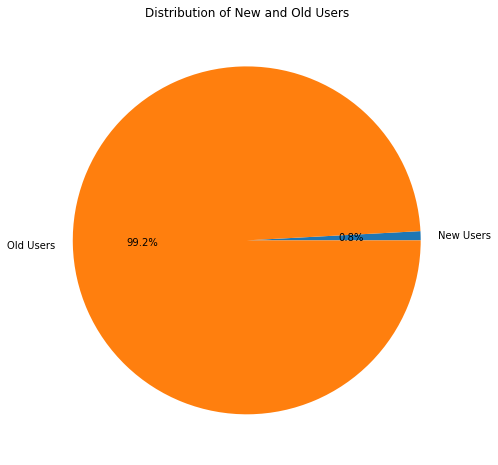

In [50]:
# Pie chart
data_user_counts = {'New Users': 127, 'Old Users': 14872}
plt.figure(figsize=(8, 8))

plt.pie(data_user_counts.values(),
       labels=data_user_counts.keys(),
       autopct='%1.1f%%')

plt.title('Distribution of New and Old Users')
plt.show()

### **Key Takeaways**
